https://www.kaggle.com/datasets/palakjain9/1000-drugs-and-side-effects

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import seaborn.objects as so

In [36]:
df = pd.read_csv('real_drug_dataset.csv')

In [3]:
df.sample(5)

,Patient_ID,Age,Gender,Condition,Drug_Name,Dosage_mg,Treatment_Duration_days,Side_Effects,Improvement_Score
585,P0586,67,Female,Hypertension,Metoprolol,50,6,Dizziness,5.8
695,P0696,68,Male,Depression,Escitalopram,850,46,Nausea,7.1
39,P0040,76,Female,Infection,Amoxicillin,250,40,Diarrhea,7.7
142,P0143,34,Female,Pain Relief,Paracetamol,500,43,Fatigue,8.0
289,P0290,54,Female,Infection,Amoxicillin,100,7,Allergy,6.1


**Cleaning dataset**

No duplicated values

In [4]:
df.duplicated().sum()

np.int64(0)

Stripping empy spaces

In [29]:
for col in df.select_dtypes(include='string').columns:
    df[col] = df[col].str.strip()

No null values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   str    
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   str    
 3   Condition                1000 non-null   str    
 4   Drug_Name                1000 non-null   str    
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   str    
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 70.4 KB


Data types looks good

**Cheking outliers.**

<Axes: >

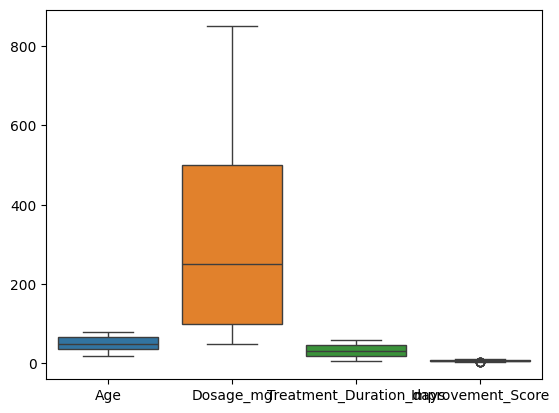

In [6]:
sns.boxplot(data=df.select_dtypes(include='number'))

Dosage_treatment class skewed but has none outliers. I think it provides a little bit of separation over the other classes.

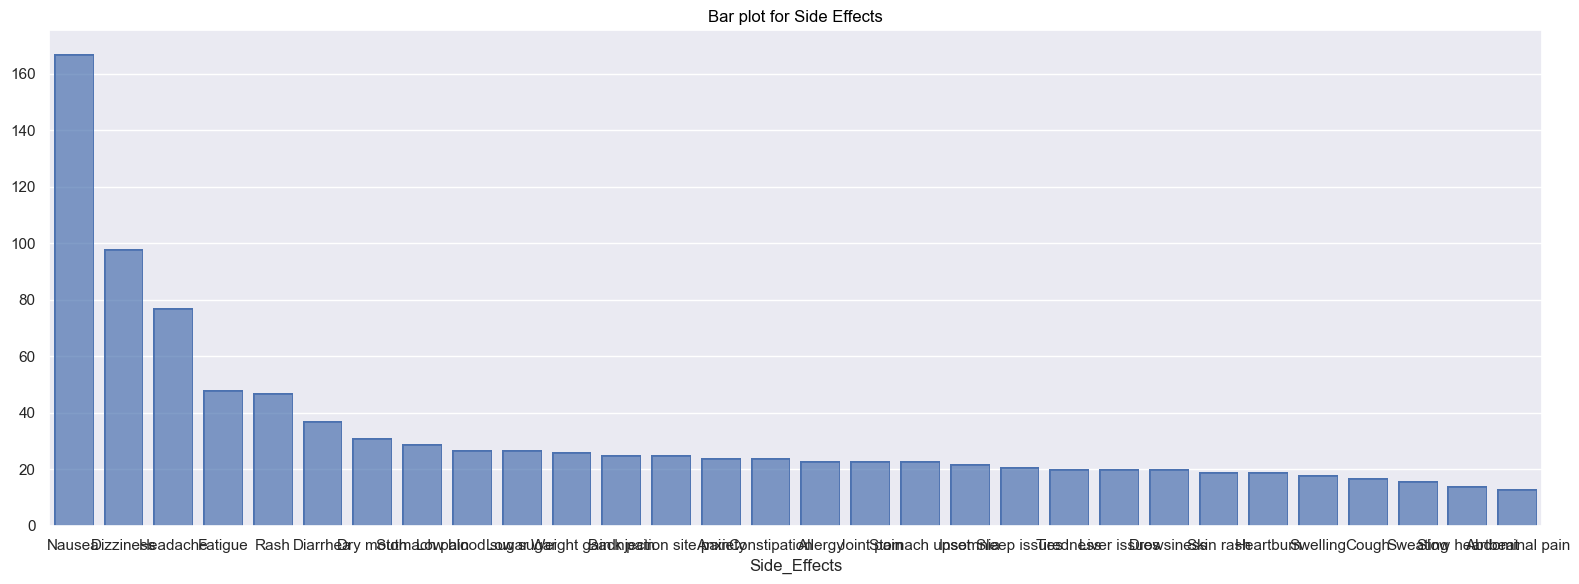

In [7]:
order = df['Side_Effects'].value_counts().index.tolist()

(
    so.Plot(df, x='Side_Effects')
    .add(so.Bar(), so.Count())
    .scale(x=so.Nominal(order=order))   #set order using frequency
    .label(title='Bar plot for Side Effects')    
    .layout(size=(16, 6))
).show()

Nausea and dizziness are the most common side effects.

In [8]:
df.Side_Effects.value_counts().head()

Side_Effects
Nausea       167
Dizziness     98
Headache      77
Fatigue       48
Rash          47
Name: count, dtype: int64

**Checking correlation between numerical variables.**

In [9]:
df.select_dtypes(include='number').corr(method='pearson').style.background_gradient(cmap='Blues')

,Age,Dosage_mg,Treatment_Duration_days,Improvement_Score
Age,1.000000,0.085434,-0.001893,0.010546
Dosage_mg,0.085434,1.000000,-0.002883,0.038349
Treatment_Duration_days,-0.001893,-0.002883,1.000000,0.049440
Improvement_Score,0.010546,0.038349,0.049440,1.000000


Correlation is pretty low between numerical variables. There aren't colineal columns.

In [10]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Age'], df['Improvement_Score'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.23788246431346283


No p-values below .05 (tested for each combination)

**Side Effects class prediction**

I'm going to try to predict the side effects using a RandomForestClassifier.

In [11]:
df.Side_Effects.unique()

<StringArray>
[             'Nausea',           'Tiredness',           'Dry mouth',
     'Low blood sugar',             'Anxiety',           'Dizziness',
        'Liver issues',            'Headache',      'Abdominal pain',
           'Low sugar',           'Back pain',           'Skin rash',
         'Weight gain',            'Insomnia',            'Diarrhea',
            'Sweating',        'Constipation',             'Allergy',
             'Fatigue',                'Rash',            'Swelling',
               'Cough',          'Joint pain',       'Stomach upset',
          'Drowsiness', 'Injection site pain',        'Sleep issues',
        'Stomach pain',      'Slow heartbeat',           'Heartburn']
Length: 30, dtype: str

I'm going to unify some Side Effects because some of them are refering to the same symptom and there are lots of them relative to the training data.

In [12]:
map = {
    "Skin rash": "Rash",
    "Rash": "Rash",

    "Low sugar": "Hypoglycemia",
    "Low blood sugar": "Hypoglycemia",

    "Stomach pain": "Abdominal pain",
    "Stomach upset": "Gastrointestinal discomfort",
    "Abdominal pain": "Gastrointestinal discomfort",

    "Fatigue": "Fatigue",
    "Tiredness": "Fatigue",

    "Drowsiness": "Sedation",
    "Sleep issues": "Sedation",

    "Allergy": "Allergy / Hypersensitivity"
}

df["Side_Effects_clean"] = df["Side_Effects"].replace(map)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [14]:
num_cols = [
    "Age",
    "Dosage_mg",
    "Treatment_Duration_days",
    "Improvement_Score"
]

cat_cols = [
    "Gender",
    "Condition",
    "Drug_Name"
]

preprocess = ColumnTransformer([
    ("cat", Pipeline([
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

In [15]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

clf = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

In [16]:
X = df.drop(columns='Side_Effects')
y = df["Side_Effects_clean"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices

**Testing the model. Scoring.**

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                             precision    recall  f1-score   support

             Abdominal pain       0.38      1.00      0.55         6
 Allergy / Hypersensitivity       0.00      0.00      0.00         5
                    Anxiety       0.33      0.60      0.43         5
                  Back pain       0.40      0.40      0.40         5
               Constipation       0.00      0.00      0.00         5
                      Cough       0.00      0.00      0.00         3
                   Diarrhea       0.25      0.57      0.35         7
                  Dizziness       0.35      0.45      0.39        20
                  Dry mouth       0.00      0.00      0.00         6
                    Fatigue       0.36      0.29      0.32        14
Gastrointestinal discomfort       0.00      0.00      0.00         7
                   Headache       0.41      0.47      0.44        15
                  Heartburn       0.00      0.00      0.00         4
               Hypoglycemia      

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

F1 scores are low for several cases wich indicates the model fails for those categories.

**Confussion Matrix**

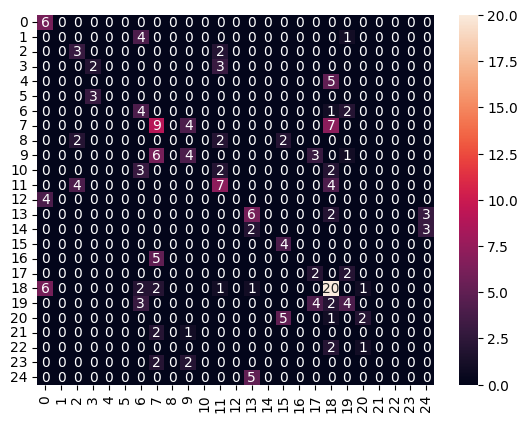

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.show()

The model fails to categorize Side Effects correctly. Data provided is not enough to improve the model.

One way to upgrade the model is to group Side Effects by the body system it involves (less categories). This loses fine detail but helps the model to improve.